# Tester_branch에서 최종 모델 성능 확인 진행

In [13]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

''' 코드 작성 바랍니다 '''

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target 

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# DT 모델링 성능

Best Hyper-parameter: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9224137931034484


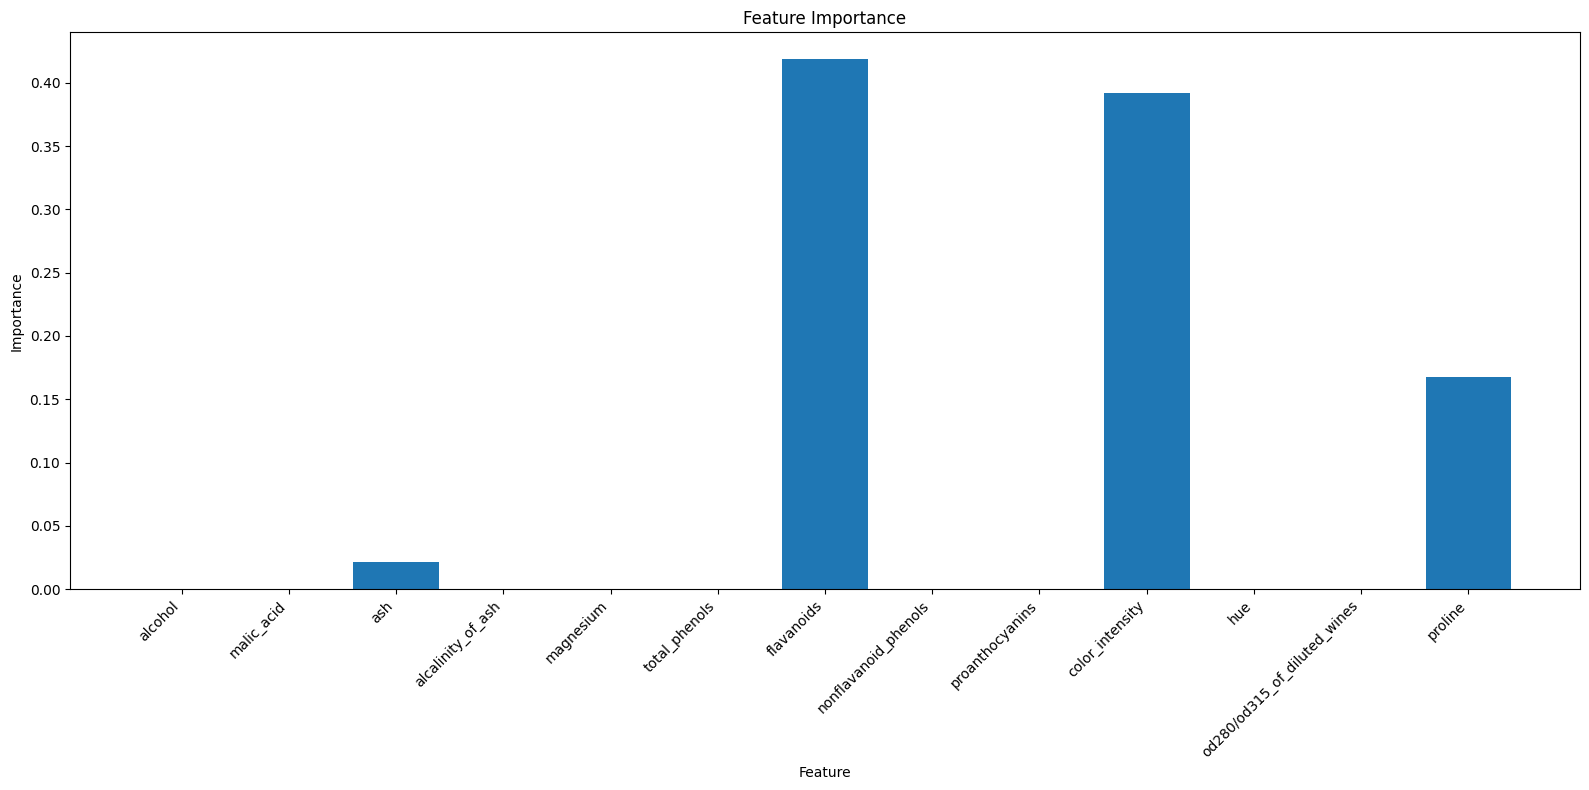

In [14]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    dt_model,
    param_grid_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

dt_pred = best_dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Best Hyper-parameter:", grid_dt.best_params_)
print("Best Score:", grid_dt.best_score_)

plt.figure(figsize=(16, 8))
plt.bar(X.columns, best_dt.feature_importances_)
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9504926108374384


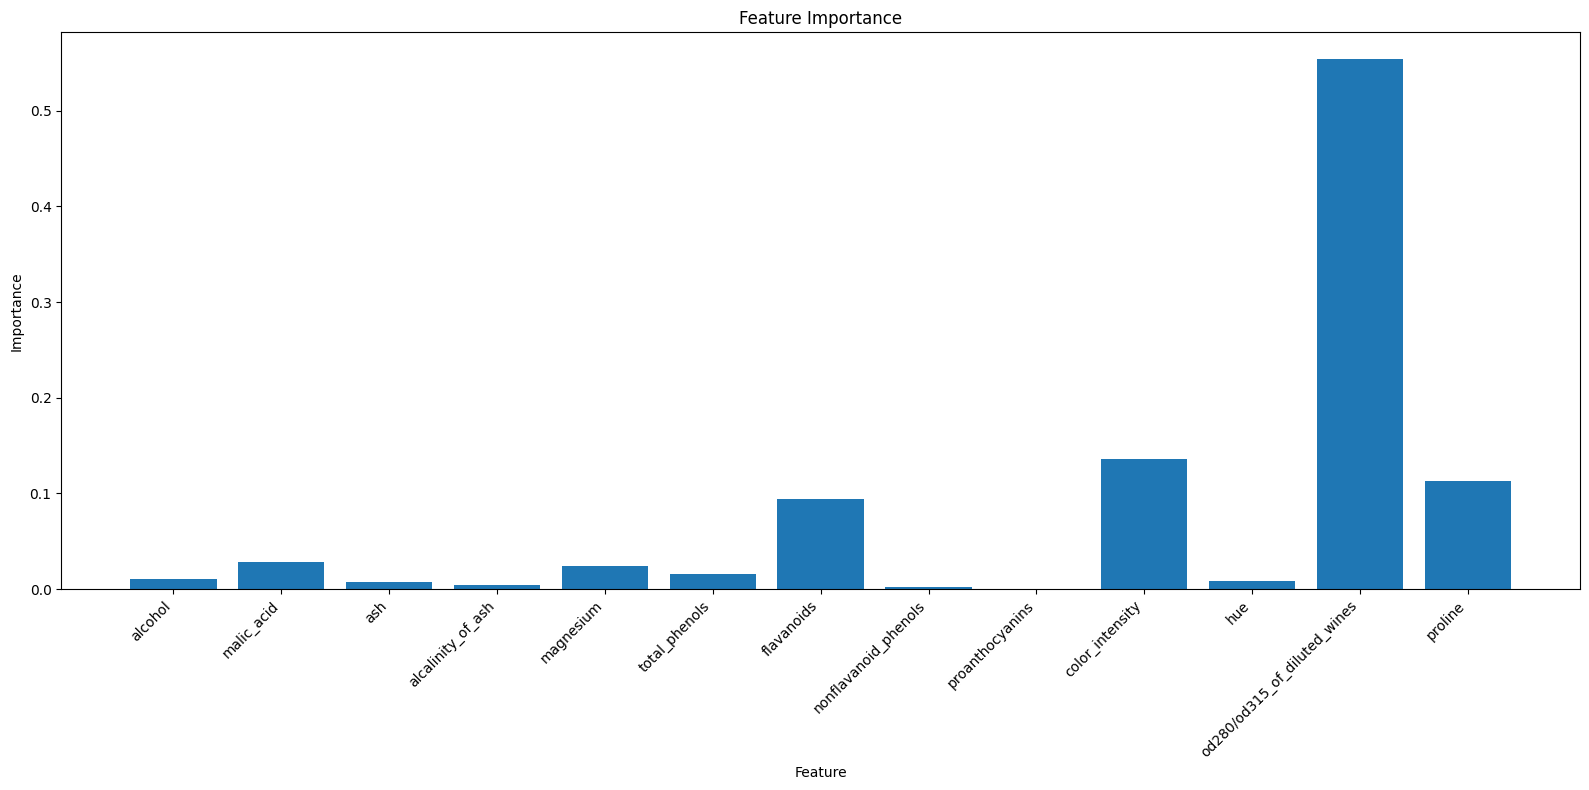

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(random_state=42)

param_grid_xgb = {
    "max_depth": [3, 5, 7, 9, 15],
    "learning_rate": [0.1, 0.01, 0.001],
    "n_estimators": [50, 100, 200, 300]
}

grid_xgb = GridSearchCV(
    xgb_model,
    param_grid_xgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

xgb_pred = best_xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Best parameters:", grid_xgb.best_params_)
print("Best accuracy:", grid_xgb.best_score_)

plt.figure(figsize=(16, 8))
plt.bar(X.columns, best_xgb.feature_importances_)
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

==================== DT 성능 확인 ====================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

==================== XGB 성능 확인 ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



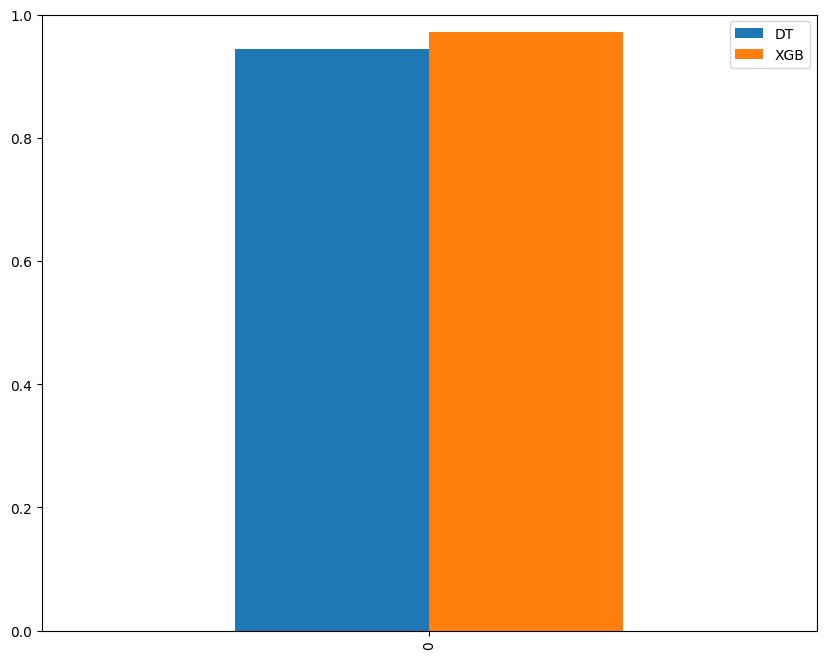

In [16]:
from sklearn.metrics import classification_report

print("=" * 20 + " DT 성능 확인 " + "=" * 20)
print(f"DT accuracy : {dt_acc}")
print(classification_report(y_test, dt_pred))

print("=" * 20 + " XGB 성능 확인 " + "=" * 20)
print(f"XGB accuracy : {xgb_acc}")
print(classification_report(y_test, xgb_pred))

plt.figure(figsize=(10, 8))

x = 0   
width = 0.2       

plt.bar(x, dt_acc, width=width, label='DT')
plt.bar(x + width, xgb_acc, width=width, label='XGB')

plt.ylim(0, 1.0)
plt.xlim(-0.3, 0.5) 
plt.xticks([x + width/2], ['0'], rotation=90) 

plt.legend()
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">